Time when signal reaches 30% DoC: 0.000 s
Time when signal reaches 90% DoC: 0.000 s
LED_Removed time T: 0.2014205
LED_Removed time T: 0.2014248
Fitted parameters for T1: [0.99032797 1.05500992 0.9123502 ]
Fitted parameters for T2: [0.99243787 1.03676396 0.93893667]
Average a=0.991
Average b=1.046
Average c=0.926


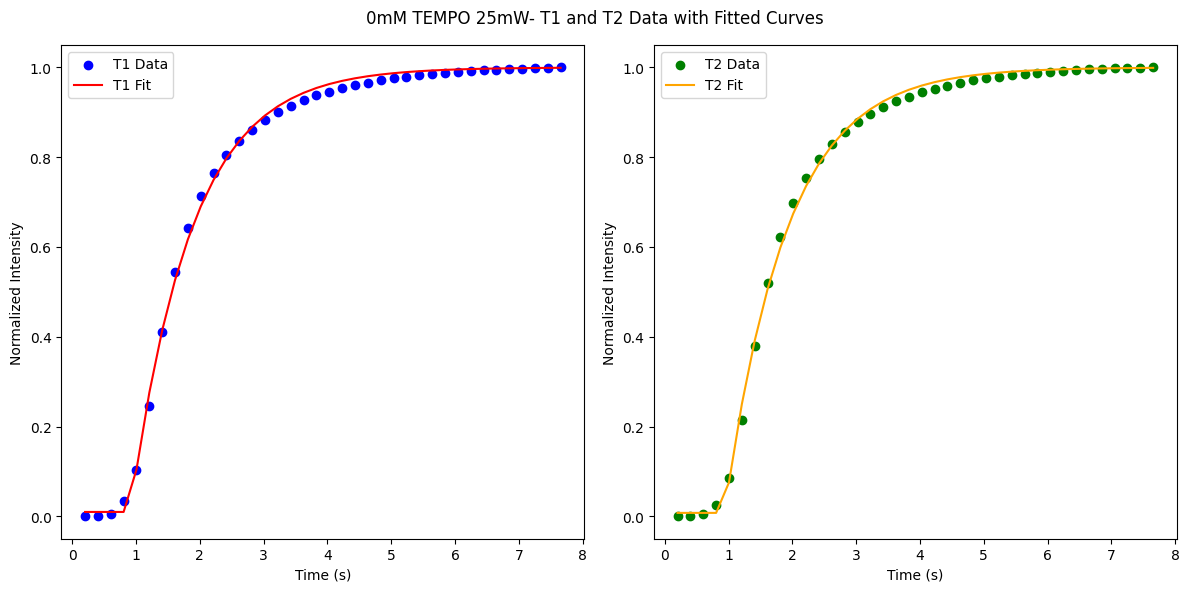

In [22]:
#This is for 0mM TEMPO (Jack Shared on April 28th)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

file_path='.\\circles_TEMPO_10,15,20,25mW_0,1,5mM\\0mM TEMPO\\25mW 0mM TEMPO\\intensity_data.csv'
df=pd.read_csv(file_path)
df.dropna(inplace=True)
#print(df.head(5))
time1=df['25mW_0_mM_TEMPO_T1_Time_s'].values
signal1=df['25mW_0_mM_TEMPO_T1_Intensity'].values

t30_1=next((time1[i] for i in range(len(signal1)) if signal1[i] >= 0.3), None)
t90_1=next((time1[i] for i in range(len(signal1)) if signal1[i] >= 0.9), None)


time2=df['25mW_0_mM_TEMPO_T2_Time_s'].values
signal2=df['25mW_0_mM_TEMPO_T2_Intensity'].values

t30_2=next((time2[i] for i in range(len(signal2)) if signal2[i] >= 0.3), None)
t90_2=next((time2[i] for i in range(len(signal2)) if signal2[i] >= 0.9), None)


print(f'Time when signal reaches 30% DoC: {np.average([t30_1, t30_2]):.3f} s')
print(f'Time when signal reaches 90% DoC: {np.average([t90_1, t90_2]):.3f} s')

for i in range(0,10):
    #print(i,signal1[i+1]-signal1[i])
    if np.abs((signal1[i+1]-signal1[i])/(signal1[i+2]-signal1[i+1]))>10:
        break
print('LED_Removed time T:',time1[i+1])
time1=time1[i+1:]
signal1=signal1[i+1:]
signal1=signal1-signal1[0]
signal1=signal1/signal1.max()

#plt.plot(time1,signal1,'--')

for i in range(0,10):
    #print(i,signal1[i+1]-signal1[i])
    if np.abs((signal2[i+1]-signal2[i])/(signal2[i+2]-signal2[i+1]))>10:
        break
print('LED_Removed time T:',time2[i+1])
time2=time2[i+1:]
signal2=signal2[i+1:]
signal2=signal2-signal2[0]
signal2=signal2/signal2.max()

def fitting_func(t,a,b,c):
    return 1-a*np.exp(np.minimum(b*(c-t),0))

popt1, pcov1 = curve_fit(fitting_func, time1, signal1)
popt2, pcov2 = curve_fit(fitting_func, time2, signal2)
print('Fitted parameters for T1:', popt1)
print('Fitted parameters for T2:', popt2)
print(f'Average a={np.mean([popt1[0], popt2[0]]):.3f}')
print(f'Average b={np.mean([popt1[1], popt2[1]]):.3f}')
print(f'Average c={np.mean([popt1[2], popt2[2]]):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].scatter(time1, signal1, label='T1 Data', color='blue')
axes[0].plot(time1, fitting_func(time1, *popt1), label='T1 Fit', color='red')
axes[1].scatter(time2, signal2, label='T2 Data', color='green')
axes[1].plot(time2, fitting_func(time2, *popt2), label='T2 Fit', color='orange')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Normalized Intensity')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Normalized Intensity')
axes[0].legend()
axes[1].legend()
fig.suptitle('0mM TEMPO 25mW- T1 and T2 Data with Fitted Curves')
fig.tight_layout()
plt.show()






Time when signal reaches 30% DoC: 1.813 s
Time when signal reaches 90% DoC: 3.827 s
LED_Removed time T: 0.2014261
LED_Removed time T: 0.2014331
Fitted parameters for T1: [0.91355063 1.022757   1.4924373 ]
Fitted parameters for T2: [0.91268842 1.05058254 1.47249072]
Average a=0.913
Average b=1.037
Average c=1.482


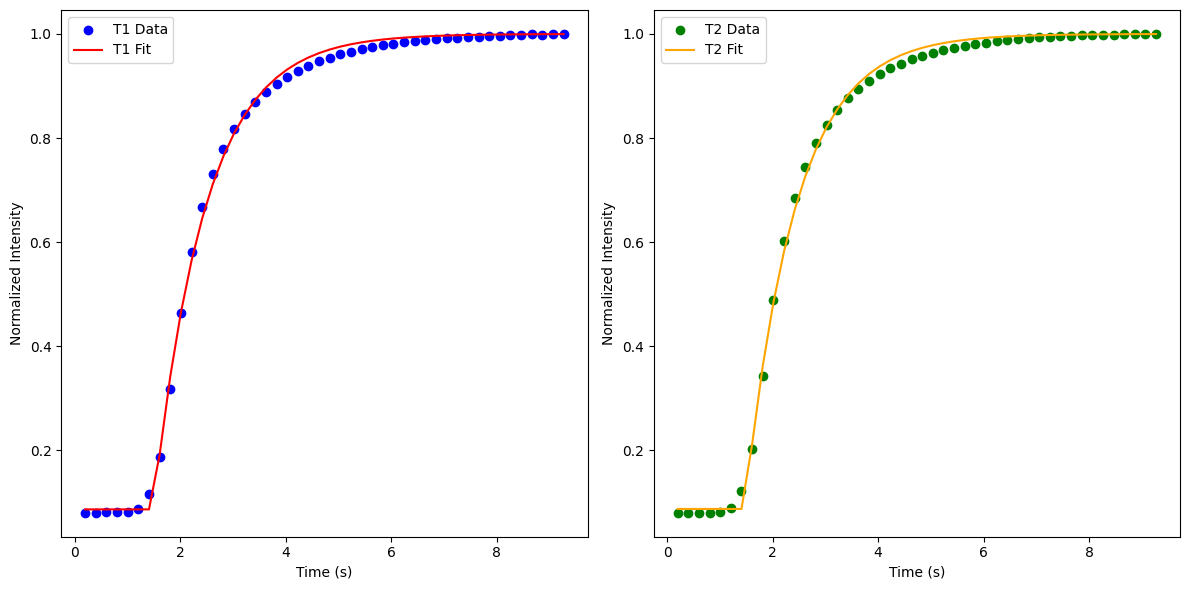

In [36]:
#This is for 1mM TEMPO (Jack Shared on April 28th)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

file_path='.\\circles_TEMPO_10,15,20,25mW_0,1,5mM\\1mM TEMPO\\25mW 1mM TEMPO\\intensity_data.csv'
df=pd.read_csv(file_path)
df.dropna(inplace=True)
#print(df.head(5))
time1=df['25mW_1_mM_TEMPO_T1_Time_s'].values
signal1=df['25mW_1_mM_TEMPO_T1_Intensity'].values
signal1=signal1/signal1.max()
t30_1=next((time1[i] for i in range(len(signal1)) if signal1[i] >= 0.3), None)
t90_1=next((time1[i] for i in range(len(signal1)) if signal1[i] >= 0.9), None)

time2=df['25mW_1_mM_TEMPO_T2_Time_s'].values
signal2=df['25mW_1_mM_TEMPO_T2_Intensity'].values
signal2=signal2/signal2.max()
t30_2=next((time2[i] for i in range(len(signal2)) if signal2[i] >= 0.3), None)
t90_2=next((time2[i] for i in range(len(signal2)) if signal2[i] >= 0.9), None)

print(f'Time when signal reaches 30% DoC: {np.average([t30_1, t30_2]):.3f} s')
print(f'Time when signal reaches 90% DoC: {np.average([t90_1, t90_2]):.3f} s')

for i in range(0,10):
    #print(i,signal1[i+1]-signal1[i])
    if np.abs((signal1[i+1]-signal1[i])/(signal1[i+2]-signal1[i+1]))>10:
        break
print('LED_Removed time T:',time1[i+1])
time1=time1[i+1:]
signal1=signal1[i+1:]

#plt.plot(time1,signal1,'--')

for i in range(0,10):
    #print(i,signal1[i+1]-signal1[i])
    if np.abs((signal2[i+1]-signal2[i])/(signal2[i+2]-signal2[i+1]))>10:
        break
print('LED_Removed time T:',time2[i+1])
time2=time2[i+1:]
signal2=signal2[i+1:]

#plt.plot(time2,signal2,'--')

def fitting_func(t,a,b,c):
    return 1-a*np.exp(np.minimum(b*(c-t),0))

popt1, pcov1 = curve_fit(fitting_func, time1, signal1)
popt2, pcov2 = curve_fit(fitting_func, time2, signal2)
print('Fitted parameters for T1:', popt1)
print('Fitted parameters for T2:', popt2)

print(f'Average a={np.mean([popt1[0], popt2[0]]):.3f}')
print(f'Average b={np.mean([popt1[1], popt2[1]]):.3f}')
print(f'Average c={np.mean([popt1[2], popt2[2]]):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].scatter(time1, signal1, label='T1 Data', color='blue')
axes[0].plot(time1, fitting_func(time1, *popt1), label='T1 Fit', color='red')
axes[1].scatter(time2, signal2, label='T2 Data', color='green')
axes[1].plot(time2, fitting_func(time2, *popt2), label='T2 Fit', color='orange')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Normalized Intensity')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Normalized Intensity')
axes[0].legend()
axes[1].legend()
fig.tight_layout()
plt.show()


Time when signal reaches 30% DoC: 4.230 s
Time when signal reaches 90% DoC: 6.345 s
Fitted parameters for T1: [0.91870246 0.94183914 3.78077131]
Fitted parameters for T2: [0.91680271 0.91441598 3.80814214]
Average a=0.918
Average b=0.928
Average c=3.794


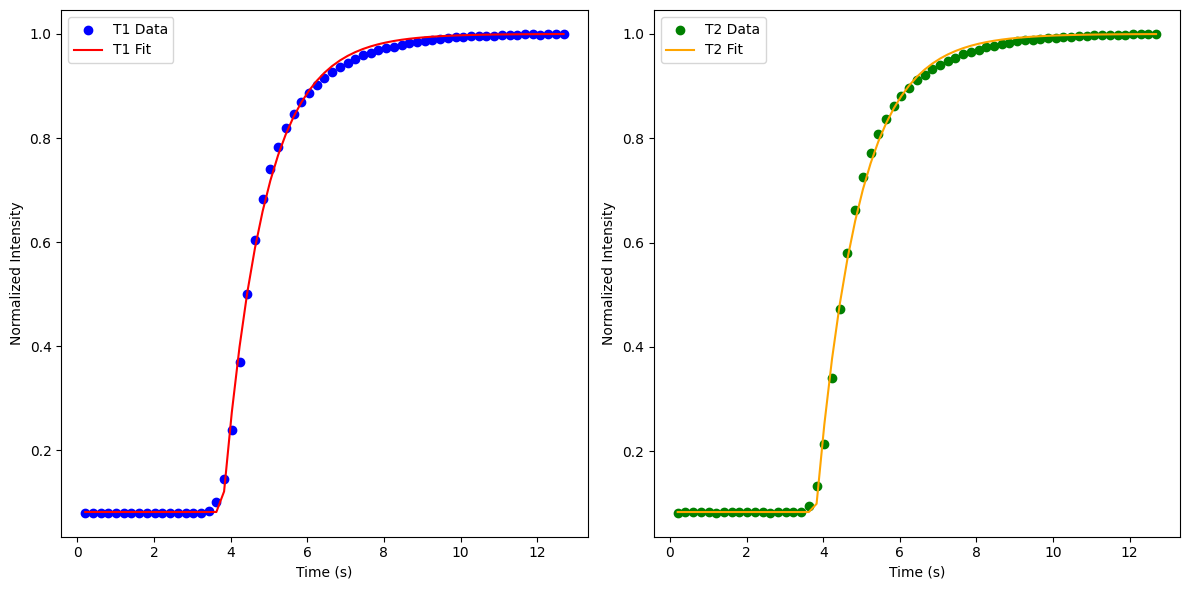

In [32]:
#This is for 5mM TEMPO (Jack Shared on April 28th)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

file_path='.\\circles_TEMPO_10,15,20,25mW_0,1,5mM\\5mM TEMPO\\25mW 5mM TEMPO\\intensity_data.csv'
df=pd.read_csv(file_path)
df.dropna(inplace=True)
#df=df.dropna(subset=['10mW_5_mM_TEMPO_T1_Time_s','10mW_5_mM_TEMPO_T1_Intensity','10mW_5_mM_TEMPO_T2_Time_s','10mW_5_mM_TEMPO_T2_Intensity'])
#print(df.head(5))
time1=df['25mW_5_mM_TEMPO_T1_Time_s'].values
signal1=df['25mW_5_mM_TEMPO_T1_Intensity'].values
signal1=signal1/signal1.max()
t30_1=next((time1[i] for i in range(len(signal1)) if signal1[i] >= 0.3), None)
t90_1=next((time1[i] for i in range(len(signal1)) if signal1[i] >= 0.9), None)

time2=df['25mW_5_mM_TEMPO_T2_Time_s'].values
signal2=df['25mW_5_mM_TEMPO_T2_Intensity'].values
signal2=signal2/signal2.max()
t30_2=next((time2[i] for i in range(len(signal2)) if signal2[i] >= 0.3), None)
t90_2=next((time2[i] for i in range(len(signal2)) if signal2[i] >= 0.9), None)
#plt.plot(signal2)

print(f'Time when signal reaches 30% DoC: {np.average([t30_1, t30_2]):.3f} s')
print(f'Time when signal reaches 90% DoC: {np.average([t90_1, t90_2]):.3f} s')

for i in range(0,10):
    #print(i,signal1[i+1]-signal1[i])
    if np.abs((signal1[i+1]-signal1[i])/(signal1[i+2]-signal1[i+1]))>5:
        break
#print('LED_Removed time T:',time1[i+1])
time1=time1[i+1:]
signal1=signal1[i+1:]

#plt.plot(time1,signal1,'--')

for i in range(0,5):
    #print(signal2[i+1]-signal2[i])
    if np.abs((signal2[i+1]-signal2[i])/(signal2[i+2]-signal2[i+1]))>5:
        break
#print('LED_Removed time T:',time2[i+1])
time2=time2[i+1:]
signal2=signal2[i+1:]
#plt.plot(time2,signal2,'--')

def fitting_func(t,a,b,c):
    return 1-a*np.exp(np.minimum(b*(c-t),0))

popt1, pcov1 = curve_fit(fitting_func, time1, signal1)
popt2, pcov2 = curve_fit(fitting_func, time2, signal2)
print('Fitted parameters for T1:', popt1)
print('Fitted parameters for T2:', popt2)

print(f'Average a={np.mean([popt1[0], popt2[0]]):.3f}')
print(f'Average b={np.mean([popt1[1], popt2[1]]):.3f}')
print(f'Average c={np.mean([popt1[2], popt2[2]]):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].scatter(time1, signal1, label='T1 Data', color='blue')
axes[0].plot(time1, fitting_func(time1, *popt1), label='T1 Fit', color='red')
axes[1].scatter(time2, signal2, label='T2 Data', color='green')
axes[1].plot(time2, fitting_func(time2, *popt2), label='T2 Fit', color='orange')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Normalized Intensity')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Normalized Intensity')
axes[0].legend()
axes[1].legend()
fig.tight_layout()
plt.show()


Time when signal reaches 30% DoC: 0.000 s
Time when signal reaches 90% DoC: 0.000 s
LED_Removed time T: 0.2014205
LED_Removed time T: 0.2014248
Fitted parameters for T1: [0.99032797 1.05500992 0.9123502 ]
Fitted parameters for T2: [0.99243787 1.03676396 0.93893667]
Average a=0.991
Average b=1.046
Average c=0.926


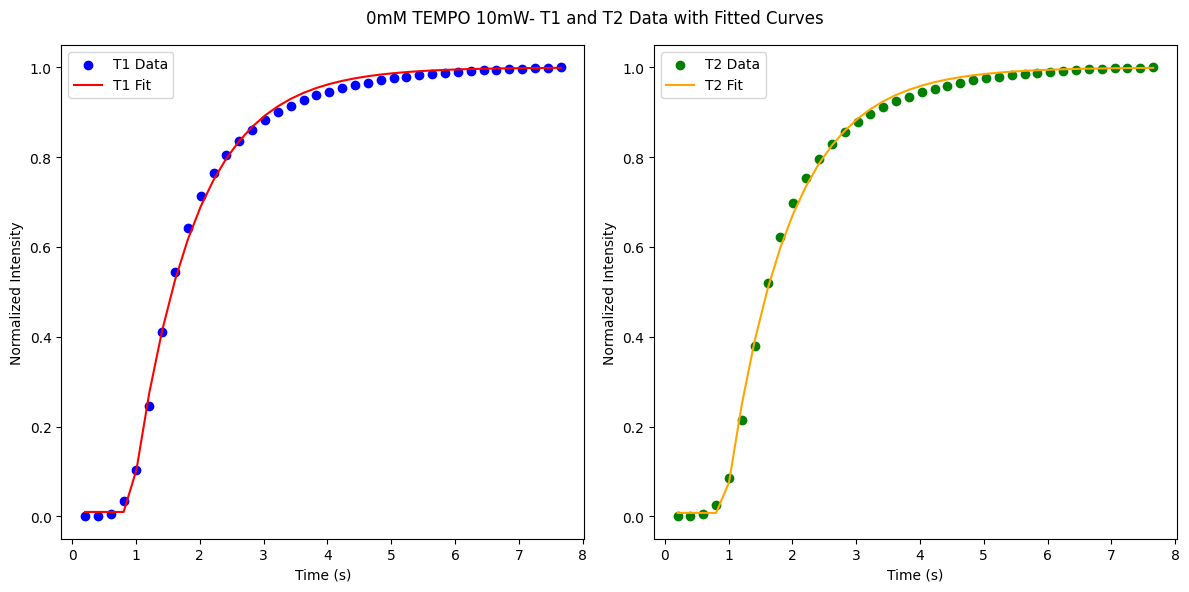

In [5]:
#This is for 0mM TEMPO (Jack Shared on April 28th)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

file_path='.\\circles_TEMPO_10,15,20,25mW_0,1,5mM\\0mM TEMPO\\25mW 0mM TEMPO\\intensity_data.csv'
df=pd.read_csv(file_path)
df.dropna(inplace=True)
#print(df.head(5))
time1=df['25mW_0_mM_TEMPO_T1_Time_s'].values
signal1=df['25mW_0_mM_TEMPO_T1_Intensity'].values
t30_1=next((time1[i] for i in range(len(signal1)) if signal1[i] >= 0.3), None)
t90_1=next((time1[i] for i in range(len(signal1)) if signal1[i] >= 0.9), None)


time2=df['25mW_0_mM_TEMPO_T2_Time_s'].values
signal2=df['25mW_0_mM_TEMPO_T2_Intensity'].values

t30_2=next((time2[i] for i in range(len(signal2)) if signal2[i] >= 0.3), None)
t90_2=next((time2[i] for i in range(len(signal2)) if signal2[i] >= 0.9), None)


print(f'Time when signal reaches 30% DoC: {np.average([t30_1, t30_2]):.3f} s')
print(f'Time when signal reaches 90% DoC: {np.average([t90_1, t90_2]):.3f} s')

for i in range(0,10):
    #print(i,signal1[i+1]-signal1[i])
    if np.abs((signal1[i+1]-signal1[i])/(signal1[i+2]-signal1[i+1]))>10:
        break
print('LED_Removed time T:',time1[i+1])
time1=time1[i+1:]
signal1=signal1[i+1:]
signal1=signal1-signal1.min()
signal1=signal1/signal1.max()

#plt.plot(time1,signal1,'--')

for i in range(0,10):
    #print(i,signal1[i+1]-signal1[i])
    if np.abs((signal2[i+1]-signal2[i])/(signal2[i+2]-signal2[i+1]))>10:
        break
print('LED_Removed time T:',time2[i+1])
time2=time2[i+1:]
signal2=signal2[i+1:]
signal2=signal2-signal2.min()
signal2=signal2/signal2.max()


def fitting_func(t,a,b,c):
    return 1-a*np.exp(np.minimum(b*(c-t),1e-10))


popt1, pcov1 = curve_fit(fitting_func, time1, signal1)
popt2, pcov2 = curve_fit(fitting_func, time2, signal2)
print('Fitted parameters for T1:', popt1)
print('Fitted parameters for T2:', popt2)
print(f'Average a={np.mean([popt1[0], popt2[0]]):.3f}')
print(f'Average b={np.mean([popt1[1], popt2[1]]):.3f}')
print(f'Average c={np.mean([popt1[2], popt2[2]]):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].scatter(time1, signal1, label='T1 Data', color='blue')
axes[0].plot(time1, fitting_func(time1, *popt1), label='T1 Fit', color='red')
axes[1].scatter(time2, signal2, label='T2 Data', color='green')
axes[1].plot(time2, fitting_func(time2, *popt2), label='T2 Fit', color='orange')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Normalized Intensity')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Normalized Intensity')
axes[0].legend()
axes[1].legend()
fig.suptitle('0mM TEMPO 10mW- T1 and T2 Data with Fitted Curves')
fig.tight_layout()
plt.show()






In [ ]:
# Automatically detect LED turn-on and trim each trace to start at LED-on.
# Raw CSV files are not changed; results are stored in trimmed_data and led_summary.
from pathlib import Path
import re
import numpy as np
import pandas as pd

DATA_ROOT = Path(r"circles_TEMPO_10,15,20,25mW_0,1,5mM")


def _time_intensity_pairs(df):
    """Yield matching Time_s / Intensity columns and ignore empty helper columns."""
    for time_col in df.columns:
        if not time_col.endswith("_Time_s"):
            continue
        intensity_col = time_col.replace("_Time_s", "_Intensity")
        if intensity_col in df.columns:
            yield time_col, intensity_col


def detect_led_turn_on(time, signal, *, min_jump=0.4, max_search_s=1.5):
    """
    Return the LED-on index and metadata.

    LED-on is the first clear positive jump before max_search_s. If the first
    frame is already near the LED plateau, the jump can be too small to detect;
    in that case, assume the first post-zero frame is LED-on and flag it.
    """
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)
    ok = np.isfinite(time) & np.isfinite(signal)
    time = time[ok]
    signal = signal[ok]

    if len(time) < 2:
        return 0, {"t_led": float(time[0]) if len(time) else np.nan, "status": "too_short", "jump": np.nan}

    dy = np.diff(signal)
    search = np.where((time[1:] <= max_search_s) & (dy >= min_jump))[0]
    if len(search):
        prev_idx = int(search[0])
        led_idx = prev_idx + 1
        return led_idx, {"t_led": float(time[led_idx]), "status": "detected_jump", "jump": float(dy[prev_idx])}

    # Fallback for traces where baseline and LED plateau are almost the same.
    post_zero = np.where(time > time[0])[0]
    led_idx = int(post_zero[0]) if len(post_zero) else 0
    jump = float(signal[led_idx] - signal[max(led_idx - 1, 0)]) if led_idx > 0 else np.nan
    return led_idx, {"t_led": float(time[led_idx]), "status": "assumed_first_postzero", "jump": jump}


def trim_trace_to_led(time, signal, **detect_kwargs):
    """Remove pre-LED samples and reset time so LED-on is t=0."""
    time = np.asarray(time, dtype=float)
    signal = np.asarray(signal, dtype=float)
    ok = np.isfinite(time) & np.isfinite(signal)
    time = time[ok]
    signal = signal[ok]
    led_idx, info = detect_led_turn_on(time, signal, **detect_kwargs)
    return time[led_idx:] - time[led_idx], signal[led_idx:], led_idx, info


def trim_intensity_dataframe(df, source_name=""):
    """Trim every T1/T2 trace in one intensity_data.csv-style DataFrame."""
    trimmed = {}
    summary = []

    for time_col, intensity_col in _time_intensity_pairs(df):
        time = df[time_col].to_numpy(dtype=float)
        signal = df[intensity_col].to_numpy(dtype=float)
        t_trim, y_trim, led_idx, info = trim_trace_to_led(time, signal)

        prefix = time_col.removesuffix("_Time_s")
        trimmed[f"{prefix}_Time_s"] = pd.Series(t_trim)
        trimmed[f"{prefix}_Intensity"] = pd.Series(y_trim)

        m = re.search(r"(\d+)mW_(\d+)_mM_TEMPO_(T[12])", prefix)
        summary.append({
            "source": source_name,
            "trace": prefix,
            "power_mW": int(m.group(1)) if m else np.nan,
            "tempo_mM": int(m.group(2)) if m else np.nan,
            "replicate": m.group(3) if m else "",
            "led_index": led_idx,
            "t_led_s": info["t_led"],
            "led_jump": info["jump"],
            "status": info["status"],
        })

    return pd.DataFrame(trimmed), pd.DataFrame(summary)


trimmed_data = {}
summary_tables = []

for csv_path in sorted(DATA_ROOT.rglob("intensity_data.csv")):
    raw_df = pd.read_csv(csv_path)
    trimmed_df, summary_df = trim_intensity_dataframe(raw_df, source_name=str(csv_path))
    trimmed_data[str(csv_path)] = trimmed_df
    summary_tables.append(summary_df)

led_summary = pd.concat(summary_tables, ignore_index=True).sort_values(["tempo_mM", "power_mW", "replicate"])
display(led_summary[["tempo_mM", "power_mW", "replicate", "t_led_s", "led_index", "led_jump", "status", "source"]])

# Example for one file:
# file_path = DATA_ROOT / "5mM TEMPO" / "20mW 5mM TEMPO" / "intensity_data.csv"
# trimmed_df, one_summary = trim_intensity_dataframe(pd.read_csv(file_path), source_name=str(file_path))
# display(one_summary)
# display(trimmed_df.head())


In [ ]:
# Detect curing onset from the LED-trimmed traces, then compute inhibition time and energy.
# Run the LED-trimming cell above first so trimmed_data and led_summary exist.
import re
import numpy as np
import pandas as pd


def detect_curing_onset(time_from_led, signal, *, plateau_points=3, min_rise=0.5, relative_rise=0.03, sustain_points=2):
    """
    Return curing-onset index and metadata for one LED-trimmed trace.

    The first few post-LED points define the inhibition plateau. Curing onset is
    the first sustained signal increase above that plateau.
    """
    time_from_led = np.asarray(time_from_led, dtype=float)
    signal = np.asarray(signal, dtype=float)
    ok = np.isfinite(time_from_led) & np.isfinite(signal)
    time_from_led = time_from_led[ok]
    signal = signal[ok]

    if len(time_from_led) < plateau_points + sustain_points + 1:
        last_idx = max(len(time_from_led) - 1, 0)
        return last_idx, {
            "t_cure_from_led_s": float(time_from_led[last_idx]) if len(time_from_led) else np.nan,
            "plateau": np.nan,
            "threshold": np.nan,
            "status": "too_short",
        }

    plateau_slice = signal[:plateau_points]
    plateau = float(np.median(plateau_slice))
    plateau_noise = float(1.4826 * np.median(np.abs(plateau_slice - plateau)))
    threshold = max(min_rise, 3 * plateau_noise, relative_rise * max(abs(plateau), 1.0))

    start_idx = plateau_points
    for idx in range(start_idx, len(signal) - sustain_points + 1):
        window = signal[idx:idx + sustain_points]
        if np.all(window > plateau + threshold):
            return idx, {
                "t_cure_from_led_s": float(time_from_led[idx]),
                "plateau": plateau,
                "threshold": float(threshold),
                "status": "detected_sustained_rise",
            }

    # Fallback: choose the largest positive-slope point after the plateau.
    dy = np.diff(signal)
    if len(dy[start_idx:]):
        idx = int(start_idx + np.argmax(dy[start_idx:]) + 1)
    else:
        idx = len(signal) - 1
    return idx, {
        "t_cure_from_led_s": float(time_from_led[idx]),
        "plateau": plateau,
        "threshold": float(threshold),
        "status": "fallback_max_slope",
    }


def detect_curing_for_trimmed_dataframe(trimmed_df, source_name=""):
    rows = []

    for time_col in trimmed_df.columns:
        if not time_col.endswith("_Time_s"):
            continue
        intensity_col = time_col.replace("_Time_s", "_Intensity")
        if intensity_col not in trimmed_df.columns:
            continue

        time_from_led = trimmed_df[time_col].to_numpy(dtype=float)
        signal = trimmed_df[intensity_col].to_numpy(dtype=float)
        cure_idx, info = detect_curing_onset(time_from_led, signal)

        prefix = time_col.removesuffix("_Time_s")
        m = re.search(r"(\d+)mW_(\d+)_mM_TEMPO_(T[12])", prefix)
        power_mw = int(m.group(1)) if m else np.nan
        tempo_mm = int(m.group(2)) if m else np.nan

        rows.append({
            "source": source_name,
            "trace": prefix,
            "tempo_mM": tempo_mm,
            "power_mW": power_mw,
            "replicate": m.group(3) if m else "",
            "curing_index_after_led": cure_idx,
            "inhibition_time_s": info["t_cure_from_led_s"],
            "inhibition_energy_mJ_cm2": info["t_cure_from_led_s"] * power_mw if np.isfinite(power_mw) else np.nan,
            "plateau_intensity": info["plateau"],
            "curing_threshold": info["threshold"],
            "curing_status": info["status"],
        })

    return pd.DataFrame(rows)


curing_summary = pd.concat(
    [detect_curing_for_trimmed_dataframe(df, source_name=path) for path, df in trimmed_data.items()],
    ignore_index=True,
).sort_values(["tempo_mM", "power_mW", "replicate"])

# Include LED absolute time for convenience. Since trimmed time starts at LED-on,
# inhibition_time_s is the curing onset time after LED turn-on.
inhibition_summary = curing_summary.merge(
    led_summary[["source", "trace", "t_led_s", "led_index", "led_jump", "status"]]
        .rename(columns={"status": "led_status"}),
    on=["source", "trace"],
    how="left",
)
inhibition_summary["t_cure_absolute_s"] = inhibition_summary["t_led_s"] + inhibition_summary["inhibition_time_s"]

cols = [
    "tempo_mM", "power_mW", "replicate", "t_led_s", "t_cure_absolute_s",
    "inhibition_time_s", "inhibition_energy_mJ_cm2", "plateau_intensity",
    "curing_threshold", "led_status", "curing_status", "source",
]
display(inhibition_summary[cols])

# Group-level check for the constant-inhibition-energy assumption.
energy_by_tempo = inhibition_summary.groupby("tempo_mM")["inhibition_energy_mJ_cm2"].agg(
    count="count", mean="mean", std="std", min="min", max="max"
)
display(energy_by_tempo)
